<a href="https://colab.research.google.com/github/majopa-cpu/prueba-summercamp/blob/main/grafica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

conexion = sqlite3.connect("torneo_smash.db")

df_original = pd.read_csv("smash_dataset_clean.csv", encoding="latin1")

df_original.to_sql("combates", conexion, if_exists="replace", index=False)

print("✅ ¡Éxito total! La base de datos relacional 'torneo_smash.db' ha sido creada y la tabla 'combates' está lista.")


✅ ¡Éxito total! La base de datos relacional 'torneo_smash.db' ha sido creada y la tabla 'combates' está lista.


In [21]:
consulta_sql = """
SELECT Nombre, Personaje, edad, Muertes
FROM combates
ORDER BY edad DESC
"""
df_filtrado = pd.read_sql_query(consulta_sql, conexion)

print("📊 Datos extraídos mediante SQL con éxito:")
df_filtrado.head(24)

📊 Datos extraídos mediante SQL con éxito:


,Nombre,Personaje,Edad,Muertes
0,Fred,Donkey Kong,21,0.0
1,Fred,Donkey Kong,21,4.0
2,Violeta,Bayoneta,20,1.0
3,Matthew,Sora,19,1.0
4,Josue,Kirby,19,1.0
5,Jonathan,Kirby,19,1.0
6,Carlos,Game and watch,16,1.0
7,Laura,Kirby,16,2.0
8,Carlos,Game and watch,16,2.0
9,Gabriel,Little mac,15,1.0


/tmp/ipykernel_734/3693031219.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_baras= sns.barplot(


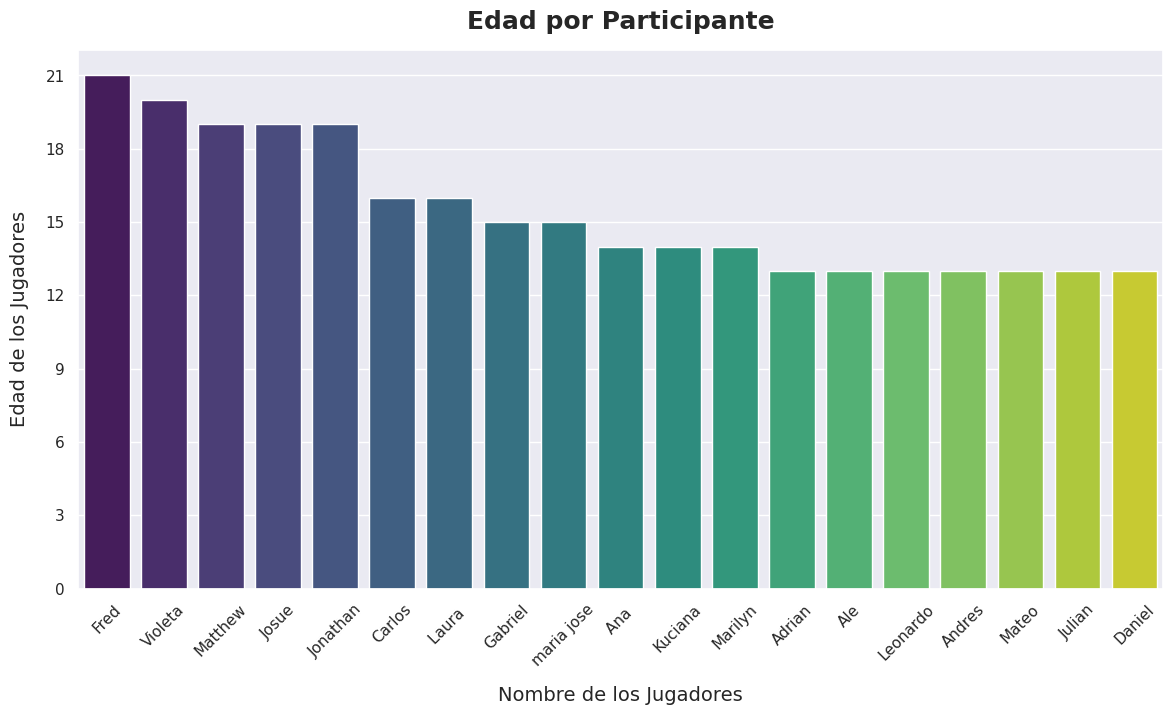

In [22]:
import matplotlib.ticker as ticker
sns.set_theme(style="darkgrid")

plt.figure(figsize=(14, 7))

grafico_baras= sns.barplot(
    data=df_filtrado,
    x="Nombre",
    y="Edad",
    palette="viridis",
    errorbar=None
)

plt.title("Edad por Participante", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Nombre de los Jugadores", fontsize=14, labelpad=12)
plt.ylabel("Edad de los Jugadores", fontsize=14, labelpad=12)

plt.xticks(rotation=45)

# Ensure y-axis ticks are integers
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.show()